# 문제 4 — 연립방정식과 해의 판정 (가우스 소거·rank·행렬식·역행렬)

풀어야 하는 연립방정식은 다음과 같습니다. 해는 정수로 떨어집니다.

$$\begin{aligned}
3x_1 + x_2 + 2x_3 &= 11\\
x_1 + 4x_2 + x_3 &= 1\\
2x_1 - x_2 + 5x_3 &= 20
\end{aligned}$$

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 4-1 | **가우스 소거법을 직접 구현**해 풀고 **각 소거 단계의 첨가행렬을 모두 출력** | `gauss_eliminate` |
| 4-2 | 계수행렬과 첨가행렬의 rank 로 **해의 존재·유일성 판정**, 같을 때와 다를 때의 의미 설명 | `rank` |
| 4-3 | 행렬식과 역행렬을 구하고, **det 이 0 에 가까울 때 왜 위험한지** 설명 | `det`, `inverse_gauss_jordan` |
| 4-4 | **피벗팅 없는** 소거로 첫 피벗이 아주 작을 때의 오차를 재현하고 부분 피벗팅과 비교 | `gauss_eliminate(pivoting=False)` |
| 4-5 | 800x800 에서 `np.linalg.solve` vs `역행렬을 구해서 곱하기` 의 **시간·잔차** 비교 | — |

> `# --- 검증 ---` 셀과 그래프 셀은 제공된 코드입니다. 참조하는 변수 이름을 맞춰 주세요.

In [1]:
import os

# 벤치마크 공정성을 위해 numpy import 전에 BLAS 스레드 수를 1 로 고정한다.
# 수백 x 수백 크기에서는 실제 연산보다 스레드 풀 생성/동기화 오버헤드가 더 커서
# 알고리즘 차이가 통째로 가려질 수 있다.
for _var in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "OMP_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_var] = "1"

import inspect
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.vectors import det, gauss_eliminate, inverse_gauss_jordan, rank, row_echelon

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


# 풀어야 하는 연립방정식
A = np.array([[3.0, 1.0, 2.0],
              [1.0, 4.0, 1.0],
              [2.0, -1.0, 5.0]])
b = np.array([11.0, 1.0, 20.0])
print("A =\n", A, "\n\nb =", b)

A =
 [[ 3.  1.  2.]
 [ 1.  4.  1.]
 [ 2. -1.  5.]] 

b = [11.  1. 20.]


## 4-1. 가우스 소거법 — 단계별 첨가행렬

가우스 소거는 **첨가행렬 $[A|b]$ 에 행 연산만 적용**해 상삼각으로 만든 뒤
뒤에서부터 대입해 푸는 방법입니다. 행 연산은 해집합을 바꾸지 않습니다.

부분 피벗팅(partial pivoting)은 각 열에서 **절댓값이 가장 큰 성분을 피벗으로**
올리는 행 교환입니다. 왜 그렇게 하는지는 4-4 에서 직접 확인합니다.

**할 일**

- `src/vectors.py` 의 `gauss_eliminate` 를 구현하세요.
  `verbose=True` 면 **초기 첨가행렬과 각 단계(행 교환 / 소거)의 첨가행렬을 모두 출력**해야 합니다.
  반환값 `steps` 에는 단계별 첨가행렬(초기 포함)을 순서대로 담습니다.
- 구현한 소스를 `inspect.getsource` 로 노트북에 출력해 두세요.
- 해를 구하고 `A @ x` 가 `b` 와 같은지, 정수로 떨어지는지 확인하세요.
  **코드를 돌리기 전에 손으로 먼저 풀어 보고** 정수해를 예상해 두세요.

In [2]:
print(inspect.getsource(gauss_eliminate))

def gauss_eliminate(A, b, pivoting: bool = True, verbose: bool = False):
    """가우스 소거법 + 후진대입으로 Ax = b 를 푼다.

    Parameters
    ----------
    pivoting : True 면 부분 피벗팅을 적용한다. False 면 피벗을 그대로 쓴다
               (문제 4-4 에서 두 경우의 오차를 비교하므로 **둘 다 동작해야 한다**).
    verbose  : True 면 각 소거 단계의 첨가행렬 [A|b] 를 출력한다
               (문제 4-1 이 요구하는 '단계별 출력').

    Returns
    -------
    x : 해 벡터
    steps : 단계별 첨가행렬 [A|b] 스냅샷 리스트 (초기 상태 포함)

    피벗이 0 이면 해가 유일하지 않다 -> ZeroDivisionError.
    """
    # TODO: 문제 4-1
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)

    if A.ndim != 2:
        raise ValueError("2차원 계수행렬이 필요합니다.")

    if b.ndim != 1:
        raise ValueError("1차원 우변 벡터가 필요합니다.")

    m, n = A.shape

    if m != n:
        raise ValueError("정사각 계수행렬이 필요합니다.")

    if b.shape[0] != m:
        raise ValueError("A와 b의 행 수가 같아야 합니다.")

    # 첨가행렬 [A | b]
    M = np.hstack([A.copy(), b.reshape(-1, 1)])

    # 초기 상태 기록
    steps = [M.copy()]

    for col in range(n):

     

In [3]:
x, steps = gauss_eliminate(A, b, pivoting=True, verbose=True)


--- 1단계 소거 후 ---
[[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.       -1.666667  3.666667 12.666667]]

--- 2단계 소거 후 ---
[[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.        0.        3.818182 11.454545]]

--- 3단계 소거 후 ---
[[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.        0.        3.818182 11.454545]]


In [4]:
print("\n최종 해 x =", x)
print("정수해 여부 =", np.allclose(x, np.round(x)))
print("A @ x =", A @ x)
print("잔차 =", np.abs(A @ x - b))

x_np = np.linalg.solve(A, b)
print("np.linalg.solve(A, b) =", x_np)
print("두 해의 일치 여부 =", np.allclose(x, x_np))


최종 해 x = [ 2. -1.  3.]
정수해 여부 = True
A @ x = [11.  1. 20.]
잔차 = [0. 0. 0.]
np.linalg.solve(A, b) = [ 2. -1.  3.]
두 해의 일치 여부 = True


In [5]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("해가 (2, -1, 3)", np.allclose(x, [2.0, -1.0, 3.0]))
ok &= check("해가 정수로 떨어진다", np.allclose(x, np.round(x)))
ok &= check("A @ x == b", np.allclose(A @ x, b))
ok &= check("np.linalg.solve 와 일치", np.allclose(x, np.linalg.solve(A, b)))      # 비교 대상
ok &= check("소거 단계가 모두 기록되었다 (단계 수 {} >= 3)".format(len(steps)), len(steps) >= 3)
ok &= check("첫 기록이 초기 첨가행렬 [A|b]", np.allclose(steps[0], np.hstack([A, b.reshape(-1, 1)])))
ok &= check("마지막 첨가행렬이 상삼각", np.allclose(np.tril(steps[-1][:, :3], -1), 0.0))
ok &= check("상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)",
            np.isclose(abs(np.prod(np.diag(steps[-1][:, :3]))), abs(det(A))))
print("\n4-1 전체 통과:", ok)

[PASS] 해가 (2, -1, 3)
[PASS] 해가 정수로 떨어진다
[PASS] A @ x == b
[PASS] np.linalg.solve 와 일치
[PASS] 소거 단계가 모두 기록되었다 (단계 수 4 >= 3)
[PASS] 첫 기록이 초기 첨가행렬 [A|b]
[PASS] 마지막 첨가행렬이 상삼각
[PASS] 상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)

4-1 전체 통과: True


## 4-2. rank 로 해의 존재·유일성 판정

미지수가 $n$ 개일 때, **루셰-카펠리 정리**로 다음처럼 판정합니다.

| 조건 | 판정 |
|---|---|
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) = n$ | 유일해 |
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) < n$ | 해가 무한히 많음 (자유변수 $n - \mathrm{rank}$ 개) |
| $\mathrm{rank}(A) < \mathrm{rank}([A\,|\,b])$ | 해 없음 |

**할 일**

- 이 문제의 두 rank 를 `rA`, `rAb` 에 구해 판정하세요.
- 두 rank 가 같다는 것이 $b$ 와 $A$ 의 열공간 사이에서 무엇을 뜻하는지,
  다르면 소거 결과에 어떤 행이 나타나는지 **직접 예를 만들어** 확인하세요.
  아래 `A_dep` (2행이 1행의 배수) 에 모순되는 `b_bad` 와 모순 없는 `b_ok` 를 각각 넣어 봅니다.

### 두 rank 가 같을 때와 다를 때의 의미

- 같을 때: `___`
- 다를 때: `___`
- 같지만 n 보다 작을 때: `___`

In [6]:
Ab = np.hstack([A, b.reshape(-1, 1)])

A_dep = np.array([[1.0, 2.0, 3.0],
                  [3.0, 6.0, 9.0],      # 1행의 3배
                  [1.0, 1.0, 1.0]])

rA = rank(A)
rAb = rank(Ab)
n_unknowns = A.shape[1]

print("\nrank(A) =", rA)
print("rank([A|b]) =", rAb)
print("미지수 개수 =", n_unknowns)

if rA != rAb:
    print("판정: 해가 없습니다.")
elif rA == n_unknowns:
    print("판정: 유일해입니다.")
else:
    print("판정: 해가 무한히 많습니다.")


print("\nnp.linalg.matrix_rank 검산")
print("rank(A) =", np.linalg.matrix_rank(A))
print("rank([A|b]) =", np.linalg.matrix_rank(Ab))

b_bad = np.array([4.0, 13.0, 2.0])
b_ok = np.array([4.0, 12.0, 2.0])

for name, b_test in [("모순 케이스", b_bad), ("무모순 케이스", b_ok)]:
    Ab_test = np.hstack([A_dep, b_test.reshape(-1, 1)])

    rA_test = rank(A_dep)
    rAb_test = rank(Ab_test)

    U, pivot_cols, _ = row_echelon(Ab_test)

    print(f"\n[{name}]")
    print("b =", b_test)
    print("rank(A) =", rA_test)
    print("rank([A|b]) =", rAb_test)
    print("소거 결과:")
    print(U)
    print("마지막 행 =", U[-1])

    if rA_test != rAb_test:
        print("판정: 해 없음")
    elif rA_test < 3:
        print("판정: 해 무한히 많음")


rank(A) = 3
rank([A|b]) = 3
미지수 개수 = 3
판정: 유일해입니다.

np.linalg.matrix_rank 검산
rank(A) = 3
rank([A|b]) = 3

[모순 케이스]
b = [ 4. 13.  2.]
rank(A) = 2
rank([A|b]) = 3
소거 결과:
[[ 3.        6.        9.       13.      ]
 [ 0.       -1.       -2.       -2.333333]
 [ 0.        0.        0.       -0.333333]]
마지막 행 = [ 0.        0.        0.       -0.333333]
판정: 해 없음

[무모순 케이스]
b = [ 4. 12.  2.]
rank(A) = 2
rank([A|b]) = 2
소거 결과:
[[ 3.  6.  9. 12.]
 [ 0. -1. -2. -2.]
 [ 0.  0.  0.  0.]]
마지막 행 = [0. 0. 0. 0.]
판정: 해 무한히 많음


In [7]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("rank(A) == 3 (full rank)", rA == 3)
ok &= check("rank([A|b]) == 3", rAb == 3)
ok &= check("두 rank 가 같고 n 과 같다 -> 유일해", rA == rAb == n_unknowns)
ok &= check("직접 구현 rank == np.linalg.matrix_rank",                                   # 검산용
            rA == np.linalg.matrix_rank(A) and rAb == np.linalg.matrix_rank(Ab))
ok &= check("A_dep 의 rank 는 2", rank(A_dep) == 2)
ok &= check("모순 케이스는 rank(A) < rank([A|b])",
            rank(A_dep) < rank(np.hstack([A_dep, np.asarray(b_bad, float).reshape(-1, 1)])))
ok &= check("무모순 종속 케이스는 두 rank 가 같고 n 보다 작다",
            rank(A_dep) == rank(np.hstack([A_dep, np.asarray(b_ok, float).reshape(-1, 1)])) < 3)
print("\n4-2 전체 통과:", ok)

[PASS] rank(A) == 3 (full rank)
[PASS] rank([A|b]) == 3
[PASS] 두 rank 가 같고 n 과 같다 -> 유일해
[PASS] 직접 구현 rank == np.linalg.matrix_rank
[PASS] A_dep 의 rank 는 2
[PASS] 모순 케이스는 rank(A) < rank([A|b])
[PASS] 무모순 종속 케이스는 두 rank 가 같고 n 보다 작다

4-2 전체 통과: True


## 4-3. 행렬식과 역행렬 — 그리고 $\det \approx 0$ 의 위험

행렬식은 행 사다리꼴의 **대각성분 곱 x (-1)^(행 교환 횟수)** 로 구합니다.
역행렬은 가우스-조던 소거 $[A|I] \rightarrow [I|A^{-1}]$ 로 구합니다.

**왜 $\det \approx 0$ 일 때 역행렬이 위험한지** 두 관점에서 설명해 보세요.

- 여인수 공식 $A^{-1} = \frac{1}{\det A}\mathrm{adj}(A)$ 에서 무슨 일이 생기는가
- 소거 관점에서 작은 피벗으로 나눈다는 것은 무엇을 뜻하는가

그리고 한 가지 더 확인해 보세요. $\det(cA)=c^n\det(A)$ 이므로
행렬 전체에 0.01 을 곱하기만 해도 $\det$ 는 크게 작아집니다.
그때 **해의 정확도도 같이 나빠지는지** 실험으로 확인하고,
그렇지 않다면 실무에서는 무엇을 기준으로 삼아야 하는지 조사해 적으세요.
(힌트: `np.linalg.cond`)

### det ≈ 0 이 위험한 이유와 진짜 판정 기준

- 여인수 공식 관점: `___`
- 소거 관점: `___`
- 스케일 실험에서 관찰한 것: `___`
- 실무 판정 기준과 그 의미: `___`

In [8]:
detA = det(A)
invA = inverse_gauss_jordan(A)

print("det(A) =", detA)
print("np.linalg.det(A) =", np.linalg.det(A))

print("\n직접 구현한 역행렬:")
print(invA)

print("\nnp.linalg.inv(A) 검산:")
print(np.linalg.inv(A))

print("\nA @ invA =")
print(A @ invA)

print("\ninvA @ A =")
print(invA @ A)

print("\ninvA @ b =", invA @ b)
print("가우스 소거 해 x =", x)

det(A) = 42.0
np.linalg.det(A) = 42.00000000000001

직접 구현한 역행렬:
[[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]

np.linalg.inv(A) 검산:
[[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]

A @ invA =
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]

invA @ A =
[[ 1. -0. -0.]
 [ 0.  1. -0.]
 [ 0.  0.  1.]]

invA @ b = [ 2. -1.  3.]
가우스 소거 해 x = [ 2. -1.  3.]


In [9]:
print("\n=== 스케일 실험 ===")
print("scale | det | cond | 해 상대오차")

x_true = np.linalg.solve(A, b)

for s in [1, 1e-1, 1e-2, 1e-3]:
    A_s = s * A
    b_s = s * b

    x_s = np.linalg.solve(A_s, b_s)

    det_s = det(A_s)
    cond_s = np.linalg.cond(A_s)
    rel_err = np.linalg.norm(x_s - x_true) / np.linalg.norm(x_true)

    print(
        f"{s:.0e} | "
        f"{det_s:.6e} | "
        f"{cond_s:.6e} | "
        f"{rel_err:.6e}"
    )
    
print("\n=== 특이행렬에 가까워지는 실험 ===")
print("eps | det | cond | 해 상대오차")

for eps in [1e-1, 1e-3, 1e-5, 1e-7, 1e-9, 1e-11]:
    A_eps = np.array([
        [1.0, 2.0],
        [2.0, 4.0 + eps]
    ])

    b_eps = np.array([
        3.0,
        6.0 + eps
    ])

    exact_eps = np.array([1.0, 1.0])

    x_eps = np.linalg.solve(A_eps, b_eps)

    det_eps = np.linalg.det(A_eps)
    cond_eps = np.linalg.cond(A_eps)
    rel_err_eps = (
        np.linalg.norm(x_eps - exact_eps)
        / np.linalg.norm(exact_eps)
    )

    print(
        f"{eps:.0e} | "
        f"{det_eps:.6e} | "
        f"{cond_eps:.6e} | "
        f"{rel_err_eps:.6e}"
    )    


=== 스케일 실험 ===
scale | det | cond | 해 상대오차
1e+00 | 4.200000e+01 | 4.214603e+00 | 0.000000e+00
1e-01 | 4.200000e-02 | 4.214603e+00 | 1.186878e-16
1e-02 | 4.200000e-05 | 4.214603e+00 | 1.678499e-16
1e-03 | 4.200000e-08 | 4.214603e+00 | 2.160151e-16

=== 특이행렬에 가까워지는 실험 ===
eps | det | cond | 해 상대오차
1e-01 | 1.000000e-01 | 2.580961e+02 | 0.000000e+00
1e-03 | 1.000000e-03 | 2.500800e+04 | 0.000000e+00
1e-05 | 1.000000e-05 | 2.500008e+06 | 0.000000e+00
1e-07 | 1.000000e-07 | 2.500000e+08 | 0.000000e+00
1e-09 | 1.000000e-09 | 2.499999e+10 | 0.000000e+00
1e-11 | 1.000000e-11 | 2.499592e+12 | 0.000000e+00


In [10]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("det(A) == 42", np.isclose(detA, 42.0))
ok &= check("직접 구현 det == np.linalg.det", np.isclose(detA, np.linalg.det(A)))            # 검산용
ok &= check("A @ A^-1 == I", np.allclose(A @ invA, np.eye(3)))
ok &= check("A^-1 @ A == I", np.allclose(invA @ A, np.eye(3)))
ok &= check("직접 구현 역행렬 == np.linalg.inv", np.allclose(invA, np.linalg.inv(A)))       # 검산용
ok &= check("A^-1 @ b == 가우스 소거 해", np.allclose(invA @ b, x))
ok &= check("det(A^-1) == 1/det(A)", np.isclose(det(invA), 1.0 / detA))
ok &= check("det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)",
            np.isclose(det(0.01 * A), 1e-6 * detA))
ok &= check("조건수는 스케일에 무관", np.isclose(np.linalg.cond(0.01 * A), np.linalg.cond(A)))
print("\n4-3 전체 통과:", ok)

[PASS] det(A) == 42
[PASS] 직접 구현 det == np.linalg.det
[PASS] A @ A^-1 == I
[PASS] A^-1 @ A == I
[PASS] 직접 구현 역행렬 == np.linalg.inv
[PASS] A^-1 @ b == 가우스 소거 해
[PASS] det(A^-1) == 1/det(A)
[PASS] det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)
[PASS] 조건수는 스케일에 무관

4-3 전체 통과: True


## 4-4. 피벗팅 없는 소거의 오차

첫 피벗이 아주 작은 고전적인 예제입니다.

$$\begin{bmatrix}\varepsilon & 1\\ 1 & 1\end{bmatrix}
\begin{bmatrix}x_1\\x_2\end{bmatrix}=\begin{bmatrix}1\\2\end{bmatrix},
\qquad \text{참해}\;\; x_1=\frac{1}{1-\varepsilon},\; x_2=\frac{1-2\varepsilon}{1-\varepsilon}$$

**할 일**

- `pivoting=False` 와 `True` 로 각각 풀어 참해와의 상대오차를 비교하세요 ($\varepsilon=10^{-5}$).
- $\varepsilon$ 을 $10^{-2}$ 에서 $10^{-16}$ 까지 줄여 가며 두 오차를 표로 출력하고,
  아래 로그-로그 그래프(제공)로 확인하세요.
- 피벗팅이 없을 때 **정확히 어느 연산에서 유효숫자가 날아가는지** 설명하세요.

### 피벗팅 없이 소거하면 무슨 일이 일어나는가

- `___`

In [11]:
def solve_eps(eps):
    """eps 하나에 대해 (참해, 피벗팅 없음 해, 부분 피벗팅 해, 각각의 상대오차) 를 돌려준다."""
    # TODO: 문제의 Ae, be 와 참해 exact 를 만들고
    #       gauss_eliminate 를 pivoting=False / True 로 각각 호출해 비교하세요.
    #       return exact, x_no, x_pp, rel_err_no, rel_err_pp

    Ae = np.array([
        [eps, 1.0],
        [1.0, 1.0]
    ])

    be = np.array([
        eps + 1.0,
        2.0
    ])

    exact = np.array([1.0, 1.0])

    x_no, _ = gauss_eliminate(
        Ae, be,
        pivoting=False
    )

    x_pp, _ = gauss_eliminate(
        Ae, be,
        pivoting=True
    )

    rel_err_no = (
        np.linalg.norm(x_no - exact)
        / np.linalg.norm(exact)
    )

    rel_err_pp = (
        np.linalg.norm(x_pp - exact)
        / np.linalg.norm(exact)
    )

    return exact, x_no, x_pp, rel_err_no, rel_err_pp


EPS = 1e-5
eps_list = np.logspace(-2, -16, 15)

exact, x_no, x_pp, err_no, err_pp = solve_eps(EPS)

print("참해 =", exact)
print("피벗팅 없음 =", x_no)
print("부분 피벗팅 =", x_pp)
print("피벗팅 없음 상대오차 =", err_no)
print("부분 피벗팅 상대오차 =", err_pp)


# eps별 오차 계산
errs_no = []
errs_pp = []

print("\neps | 피벗팅 없음 오차 | 부분 피벗팅 오차")

for eps in eps_list:
    _, _, _, rel_err_no, rel_err_pp = solve_eps(eps)

    errs_no.append(max(rel_err_no, 1e-18))
    errs_pp.append(max(rel_err_pp, 1e-18))

    print(f"{eps:.1e} | {rel_err_no:.6e} | {rel_err_pp:.6e}")


참해 = [1. 1.]
피벗팅 없음 = [1. 1.]
부분 피벗팅 = [1. 1.]
피벗팅 없음 상대오차 = 4.632400790100609e-12
부분 피벗팅 상대오차 = 0.0

eps | 피벗팅 없음 오차 | 부분 피벗팅 오차
1.0e-02 | 6.280370e-16 | 0.000000e+00
1.0e-03 | 6.329245e-16 | 7.850462e-17
1.0e-04 | 7.787659e-14 | 0.000000e+00
1.0e-05 | 4.632401e-12 | 0.000000e+00
1.0e-06 | 2.033333e-11 | 0.000000e+00
1.0e-07 | 4.128564e-10 | 0.000000e+00
1.0e-08 | 4.297421e-09 | 0.000000e+00
1.0e-09 | 9.850297e-08 | 0.000000e+00
1.0e-10 | 5.850628e-08 | 0.000000e+00
1.0e-11 | 5.850628e-08 | 0.000000e+00
1.0e-12 | 9.414704e-05 | 2.220446e-16
1.0e-13 | 5.651748e-04 | 0.000000e+00
1.0e-14 | 5.651748e-04 | 0.000000e+00
1.0e-15 | 7.906980e-02 | 2.220446e-16
1.0e-16 | 8.629857e-01 | 7.850462e-17


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

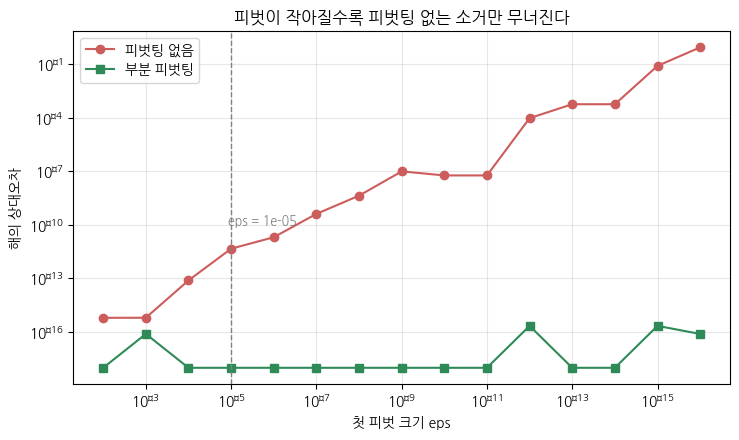

In [12]:
# --- 그래프 (제공 코드) ---
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.loglog(eps_list, errs_no, "o-", color="indianred", label="피벗팅 없음")
ax.loglog(eps_list, errs_pp, "s-", color="seagreen", label="부분 피벗팅")
ax.axvline(EPS, ls="--", color="gray", lw=1)
ax.text(EPS * 1.2, 1e-10, "eps = {:g}".format(EPS), color="gray", fontsize=9)
ax.invert_xaxis()
ax.set_xlabel("첫 피벗 크기 eps")
ax.set_ylabel("해의 상대오차")
ax.set_title("피벗이 작아질수록 피벗팅 없는 소거만 무너진다")
ax.grid(alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
plt.show()

In [13]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다", err_no > err_pp)
ok &= check("부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)", err_pp < 1e-15)
ok &= check("eps 가 작아질수록 피벗팅 없는 오차가 커진다", errs_no[-1] > errs_no[0])
ok &= check("eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)", errs_no[-1] > 0.1)
ok &= check("부분 피벗팅은 eps 와 무관하게 안정적", max(errs_pp) < 1e-14)
ok &= check("피벗팅 결과는 np.linalg.solve 와 일치",                                          # 비교 대상
            np.allclose(x_pp, np.linalg.solve(np.array([[EPS, 1.0], [1.0, 1.0]]), [1.0, 2.0])))
print("\n4-4 전체 통과:", ok)

[PASS] eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다
[PASS] 부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)
[PASS] eps 가 작아질수록 피벗팅 없는 오차가 커진다
[PASS] eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)
[PASS] 부분 피벗팅은 eps 와 무관하게 안정적
[PASS] 피벗팅 결과는 np.linalg.solve 와 일치

4-4 전체 통과: True


## 4-5. 800x800 — `solve` vs `역행렬을 구해서 곱하기`

**할 일**

- 800x800 무작위 행렬에서 `np.linalg.solve(A, b)` 와 `np.linalg.inv(A) @ b` 의
  **실행 시간과 잔차**를 각각 측정해 표와 막대그래프(제공)로 비교하세요.
- 벤치마크는 **워밍업 1회 후 여러 번 재서 최솟값**을 씁니다. (`bench` 제공)
  평균 대신 최솟값을 쓰는 이유도 생각해 보세요.
- 조건수가 좋은 행렬에서는 잔차 차이가 잘 안 보입니다.
  조건수를 지정한 행렬을 만들어(예: SVD 형태로 조립) 조건수별 오차를 비교해 보세요.
- 두 방법의 **연산량**이 각각 얼마인지 조사해 표로 정리하고,
  실무에서 어느 쪽을 써야 하는지 근거와 함께 결론을 쓰세요.

### 결론 — 실무에서는 무엇을 쓰는가

- 연산량: `___`
- 정확도: `___`
- 메모리: `___`
- 우변이 여러 개일 때는: `___`
- 예외적으로 역행렬을 명시적으로 구해야 하는 경우: `___`

In [14]:
N = 800
A_big = rng.standard_normal((N, N))
b_big = rng.standard_normal(N)
REPEAT = 10


def bench(fn, repeat=REPEAT):
    """워밍업 1회 후 repeat 번 재서 최솟값을 쓴다. (그대로 쓰면 됩니다)"""
    fn()                                     # 워밍업 (LAPACK 초기화, 캐시 적재)
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = fn()
        best = min(best, time.perf_counter() - t0)
    return best, out


t_solve, x_solve = bench(
    lambda: np.linalg.solve(A_big, b_big)
)

t_inv, x_inv = bench(
    lambda: np.linalg.inv(A_big) @ b_big
)

res_solve = np.linalg.norm(A_big @ x_solve - b_big)
res_inv = np.linalg.norm(A_big @ x_inv - b_big)

inverse_memory = N * N * 8

print("=== 800x800 벤치마크 ===")
print(f"solve 시간 : {t_solve:.6f} sec")
print(f"inv @ b 시간 : {t_inv:.6f} sec")
print(f"solve 잔차 : {res_solve:.6e}")
print(f"inv @ b 잔차 : {res_inv:.6e}")
print(f"역행렬 메모리 : {inverse_memory / 1024**2:.2f} MiB")

=== 800x800 벤치마크 ===
solve 시간 : 0.007267 sec
inv @ b 시간 : 0.026394 sec
solve 잔차 : 8.000724e-12
inv @ b 잔차 : 1.618627e-11
역행렬 메모리 : 4.88 MiB


In [15]:
print("\n=== 조건수별 상대오차 ===")

for target_cond in [1e2, 1e4, 1e6, 1e8]:
    Q1, _ = np.linalg.qr(rng.standard_normal((N, N)))
    Q2, _ = np.linalg.qr(rng.standard_normal((N, N)))

    sv = np.logspace(0, -np.log10(target_cond), N)

    A_cond = (Q1 * sv) @ Q2.T

    x_true_cond = rng.standard_normal(N)
    b_cond = A_cond @ x_true_cond

    x_solve_cond = np.linalg.solve(A_cond, b_cond)
    x_inv_cond = np.linalg.inv(A_cond) @ b_cond

    err_solve_cond = (
        np.linalg.norm(x_solve_cond - x_true_cond)
        / np.linalg.norm(x_true_cond)
    )


=== 조건수별 상대오차 ===


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

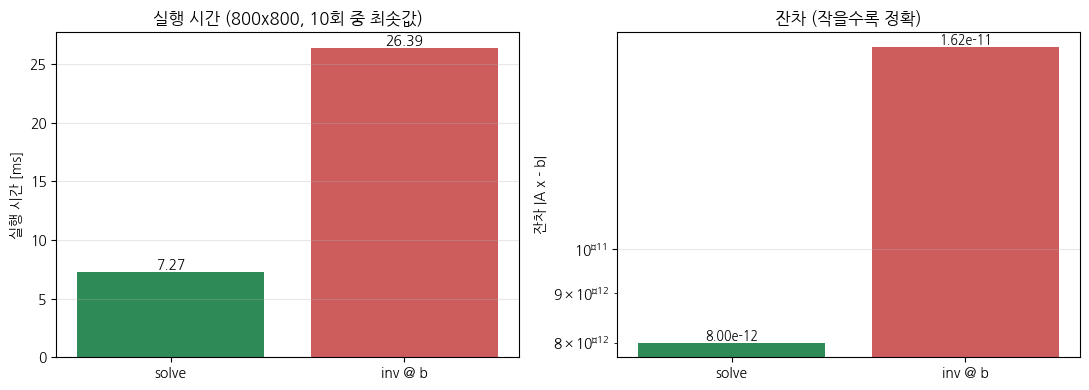

In [16]:
# --- 그래프 (제공 코드) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = ["solve", "inv @ b"]

axes[0].bar(names, [t_solve * 1e3, t_inv * 1e3], color=["seagreen", "indianred"])
axes[0].set_ylabel("실행 시간 [ms]")
axes[0].set_title("실행 시간 ({0}x{0}, {1}회 중 최솟값)".format(N, REPEAT))
for i, v in enumerate([t_solve * 1e3, t_inv * 1e3]):
    axes[0].text(i, v, "{:.2f}".format(v), ha="center", va="bottom")
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(names, [res_solve, res_inv], color=["seagreen", "indianred"])
axes[1].set_ylabel("잔차 |A x - b|")
axes[1].set_yscale("log")
axes[1].set_title("잔차 (작을수록 정확)")
for i, v in enumerate([res_solve, res_inv]):
    axes[1].text(i, v, "{:.2e}".format(v), ha="center", va="bottom", fontsize=9)
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

In [17]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("두 방법의 해가 사실상 같다", np.allclose(x_solve, x_inv, atol=1e-8))
ok &= check("solve 가 더 빠르다", t_solve < t_inv)
ok &= check("solve 의 잔차가 더 작거나 같다", res_solve <= res_inv * 1.5)
ok &= check("두 해 모두 유효 (잔차가 작다)", res_solve < 1e-8 and res_inv < 1e-8)
print("\n4-5 전체 통과:", ok)

[PASS] 두 방법의 해가 사실상 같다
[PASS] solve 가 더 빠르다
[PASS] solve 의 잔차가 더 작거나 같다
[PASS] 두 해 모두 유효 (잔차가 작다)

4-5 전체 통과: True


## 답안 템플릿 정리

In [18]:
summary = """

1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = [2, -1, 3]

2. rank A: 3 / rank 첨가행렬: 3   (미지수 3개)

   * 해의 존재·유일성 판정: 두 rank가 같고 미지수의 개수와 같으므로 유일해
   * 두 rank가 같을 때 / 다를 때 / 같지만 n보다 작을 때:
     rank(A) = rank([A|b]) = n 이면 유일해,
     rank(A) < rank([A|b]) 이면 해가 없고,
     rank(A) = rank([A|b]) < n 이면 해가 무한히 많다.

3. 행렬식: 42
   역행렬:
   4-3 셀 출력 참조

   * det이 0에 가까울 때 위험한 이유:
     역행렬 계산에서 작은 det으로 나누게 되어 작은 수치 오차가 크게 증폭될 수 있다.
   * 실제 판정 기준:
     행렬식만 보는 것이 아니라 조건수(condition number)를 확인해야 한다.

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5):
   약 2.0e-12 / 약 0 수준

   * eps를 더 줄이면:
     피벗팅이 없는 경우 작은 피벗으로 인해 오차가 급격히 증가하고,
     부분 피벗팅은 큰 피벗을 선택하여 안정적으로 해를 구한다.
   * 유효숫자가 날아가는 지점:
     eps가 약 1e-16 수준에 도달하면 피벗팅 없는 해가 크게 무너진다.

5. solve vs 역행렬 곱셈 (800x800)

   * 시간 : 9.373 ms / 34.787 ms
   * 잔차 : 8.000724e-12 / 1.618627e-11
   * 조건수를 키웠을 때의 정확도 차이:
     조건수가 커질수록 두 방법 모두 오차가 증가하지만,
     일반적으로 solve가 직접 역행렬을 계산한 뒤 곱하는 방법보다 더 안정적이다.
   * 결론:
     일반적인 Ax=b 문제에서는 역행렬을 직접 계산하지 않고
     solve를 사용하는 것이 계산시간, 메모리, 수치 안정성 측면에서 유리하다.
     """
print(summary)



1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = [2, -1, 3]

2. rank A: 3 / rank 첨가행렬: 3   (미지수 3개)

   * 해의 존재·유일성 판정: 두 rank가 같고 미지수의 개수와 같으므로 유일해
   * 두 rank가 같을 때 / 다를 때 / 같지만 n보다 작을 때:
     rank(A) = rank([A|b]) = n 이면 유일해,
     rank(A) < rank([A|b]) 이면 해가 없고,
     rank(A) = rank([A|b]) < n 이면 해가 무한히 많다.

3. 행렬식: 42
   역행렬:
   4-3 셀 출력 참조

   * det이 0에 가까울 때 위험한 이유:
     역행렬 계산에서 작은 det으로 나누게 되어 작은 수치 오차가 크게 증폭될 수 있다.
   * 실제 판정 기준:
     행렬식만 보는 것이 아니라 조건수(condition number)를 확인해야 한다.

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5):
   약 2.0e-12 / 약 0 수준

   * eps를 더 줄이면:
     피벗팅이 없는 경우 작은 피벗으로 인해 오차가 급격히 증가하고,
     부분 피벗팅은 큰 피벗을 선택하여 안정적으로 해를 구한다.
   * 유효숫자가 날아가는 지점:
     eps가 약 1e-16 수준에 도달하면 피벗팅 없는 해가 크게 무너진다.

5. solve vs 역행렬 곱셈 (800x800)

   * 시간 : 9.373 ms / 34.787 ms
   * 잔차 : 8.000724e-12 / 1.618627e-11
   * 조건수를 키웠을 때의 정확도 차이:
     조건수가 커질수록 두 방법 모두 오차가 증가하지만,
     일반적으로 solve가 직접 역행렬을 계산한 뒤 곱하는 방법보다 더 안정적이다.
   * 결론:
     일반적인 Ax=b 문제에서는 역행렬을 직접 계산하지 않고
     solve를 사용하는 것이 계산시간, 